In [1]:
import os
import json
import geopandas as gpd
import requests

import io
import zipfile

import rasterio
from rasterio.shutil import copy as rio_copy
from rasterio.enums import Resampling

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Utility functions
def get_bbox(geojson_path):
    """Extracts bounding box coordinates from an input vector data file"""
    gdf = gpd.read_file(geojson_path) # you can use a .shp file also here directly

    if gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(4326)
    bbox = tuple([float(b) for b in gdf.total_bounds])

    return bbox

In [3]:
# Use City of Ottawa urban boundary as test AOI
geojson_path = './ottawa_urban_boundary.geojson'
#geojson_path = './nwt_example.geojson'
aoi_gdf = gpd.read_file(geojson_path)
utm_crs = aoi_gdf.estimate_utm_crs().to_epsg()
bbox = get_bbox(geojson_path)
bbox

(-75.96666401487873, 45.23090774120208, -75.43410167132566, 45.516074722660285)

In [4]:
# Filter assets by imaging date
start_date = '2022-12-01T00:00:00Z'
end_date = '2025-05-31T23:59:59Z'

In [9]:
# Open EODMS STAC catalog and explore available collections
#ogc_api_url = 'https://www-staging-eodms.aws.nrcan-rncan.cloud/QGIS/eodms-qgis-server/wfs3'
#ogc_api_url = 'https://www-staging-eodms.aws.nrcan-rncan.cloud/ogc'
ogc_api_url = 'http://localhost:8081/cgi-bin/qgis_mapserv.fcgi.exe/wfs3'
# Construct the collections endpoint
collections_url = f"{ogc_api_url}/collections"
# Send a GET request to the collections endpoint
response = requests.get(collections_url)
if response.status_code == 200:
    collections = response.json() 
    print("Collections available in the OGC API:")
    num_collections = len(collections.get("collections", []))
    print(f"Number of collections: {num_collections}")
    for collection in collections.get("collections", []):
        print(f"- {collection.get('id')}: {collection.get('title')}")
else:  
    print(f"Failed to retrieve collections. Status code: {response.status_code}")


Collections available in the OGC API:
Number of collections: 7
- EGS_Flood_Footprint_Active_en: Floods in Canada - Active - Satellite Footprints
- EGS_Flood_Extent_Archive_en: Floods in Canada - Archive - Product Extents
- EGS_Flood_Footprint_Archive_en: Floods in Canada - Archive - Satellite Footprints
- EGS_Flood_Extent_Current_en: Floods in Canada - Current Year - Product Extents
- EGS_Flood_Footprint_Current_en: Floods in Canada - Current Year - Satellite Footprints
- EGS_Flood_Footprint_Seasonal_en: Floods in Canada - Seasonal - Satellite Footprints
- S2_L2A: Sentinel 2 L2A


In [13]:
# List all items in RCM-ARD collection that intersect with area of interest within date range
#collection_id = 'Sentinel2'
collection_id = 'S2_L2A'
datetime_range = f"{start_date}/{end_date}"

# Construct the search URL
search_url = f"{ogc_api_url}/collections/{collection_id}/items" #items.json for qgis
search_url

'http://localhost:8081/cgi-bin/qgis_mapserv.fcgi.exe/wfs3/collections/S2_L2A/items'

In [14]:
# Set query parameters
params = {
    "datetime": datetime_range, #capital D for ms4w - Datetime
    #"bbox":",".join(map(str, bbox)),
    "limit":3
}
params

{'datetime': '2022-12-01T00:00:00Z/2025-05-31T23:59:59Z', 'limit': 3}

In [15]:
# Make the request
response = requests.get(search_url, params=params)
desired_properties = ["producttype", "acquisition_start", "product_link"]
# Check and parse the response
if response.status_code == 200:
    features = response.json().get("features", [])
    print(f"Found {len(features)} features between {start_date} and {end_date}.")
    print("Product Type","       ", "Acquisition start","          ", "Product Link", )
    for feature in features[:10]:      
        properties = feature.get("properties", {})
        product_type = properties.get('producttype')
        acquisition_start = properties.get('acquisition_start')
        product_link = properties.get('product_link')
        print(product_type,"       ", acquisition_start,"          ", product_link)
else:
    print(f"Failed to retrieve features. Status code: {response.status_code}")
#print(product_link)

Found 3 features between 2022-12-01T00:00:00Z and 2025-05-31T23:59:59Z.
Product Type         Acquisition start            Product Link
S2MSI2A         2025-02-06T09:29:41.025-05:00            None
S2MSI2A         2025-02-06T09:29:41.025-05:00            None
S2MSI2A         2025-02-06T09:29:41.025-05:00            None


In [16]:
# Download and extract a sentinel 2 SAFE zip
if not os.path.exists('./sentinel_2_data'):
    os.mkdir('./sentinel_2_data')
# Directory to extract files to
extract_to = "./sentinel_2_data"

# Create the directory if it doesn't exist
os.makedirs(extract_to, exist_ok=True)
# Extract all files

zip_url = product_link
zip_name = os.path.splitext(os.path.basename(zip_url))[0]
# Download and extract
response = requests.get(zip_url)
if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(extract_to)

    print(f"Files extracted to '{extract_to}' '{zip_name}'")
else:
    print(f"Failed to download ZIP file. Status code: {response.status_code}")





TypeError: expected str, bytes or os.PathLike object, not NoneType

In [ ]:
def find_img_data_dir(start_path):
    for root, dirs, files in os.walk(start_path):
        if "IMG_DATA" in dirs:
            return os.path.join(root, "IMG_DATA")
    return None


In [ ]:
# Example usage:
start_directory = extract_to + "/" + zip_name + ".SAFE"
print ("directory is " + start_directory)
img_data_path = find_img_data_dir(start_directory)

if img_data_path:
    print(f"'img_data' directory found at: {img_data_path}")
else:
    print("No 'img_data' directory found.")

In [ ]:
def find_file_by_band_name(search_dir, band_to_search):
    for root, dirs, files in os.walk(search_dir):
        for file in files:
            if band_to_search in file:
                #return os.path.join(root, file)
                return root, file
    return None


In [ ]:
def find_band_jp2file_make_cog(search_dir, band_to_search):
    band_file_dir, found_file = find_file_by_band_name(directory_to_search, band_to_search)
    band_filename = os.path.splitext(os.path.basename(found_file))[0]
    if found_file:
        print(f"File found: {found_file}")
        print(f"Base name of file: {band_filename}")
        print(f"Directory of file: {band_file_dir}")
    else:
        print("No matching file found.")
     # Input JP2 file path
    input_jp2 = band_file_dir + "/" + band_filename + ".jp2"

    # Output COG file path
    output_cog = band_file_dir + "/" + band_filename + "_cog.tif"

    # Define COG profile
    cog_profile = {
        'driver': 'COG',
        'compress': 'deflate',
        'blocksize': 512,
        'overview_resampling': Resampling.nearest
    }

    # Convert JP2 to COG
    rio_copy(input_jp2, output_cog,  **cog_profile)

    print(f"Converted {input_jp2} to Cloud Optimized GeoTIFF: {output_cog}")
    return output_cog

In [ ]:
band_to_search = "_B12"
B12_cog = find_band_jp2file_make_cog(img_data_path, band_to_search)

In [ ]:
band_to_search = "_B8A"
B8A_cog = find_band_jp2file_make_cog(img_data_path, band_to_search)

In [ ]:
band_to_search = "_B04"
B04_cog = find_band_jp2file_make_cog(img_data_path, band_to_search)

In [ ]:
# Load each band from its respective COG file
with rasterio.open(B12_cog) as red_src:
    red = red_src.read(1)

with rasterio.open(B8A_cog) as green_src:
    green = green_src.read(1)

with rasterio.open(B04_cog) as blue_src:
    blue = blue_src.read(1)

# Stack into RGB format
rgb = np.stack([red, green, blue], axis=-1)


In [ ]:
def plot_RGB_cog(rgb):
    # Normalize to [0, 1] for display
    rgb_normalized = rgb.astype(np.float32)
    rgb_normalized /= rgb_normalized.max()

    # Plot using matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_normalized)
    plt.title("RGB Composite")
    plt.axis('off')
    plt.show()


In [23]:
def plot_band_cog(band_cog_file):
    # Path to your COG file
    cog_path = band_cog_file

    # Open and read the first band
    with rasterio.open(cog_path) as src:
        band1 = src.read(1)

    # Plot the band
    plt.figure(figsize=(10, 8))
    plt.imshow(band1, cmap='gray')
    #aoi_gdf.to_crs(utm_crs).plot(ax=axes[0], facecolor='none', edgecolor='brown', linewidth=2)
    plt.colorbar(label='Pixel values')
    plt.title('Single Band Visualization of COG')
    plt.xlabel('Column Index')
    plt.ylabel('Row Index')
    plt.show()


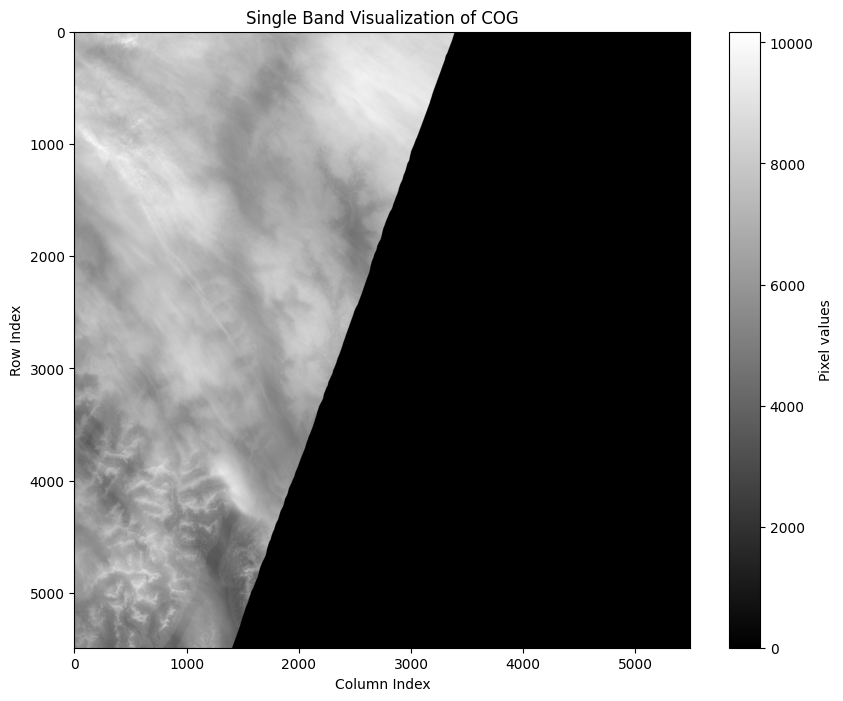

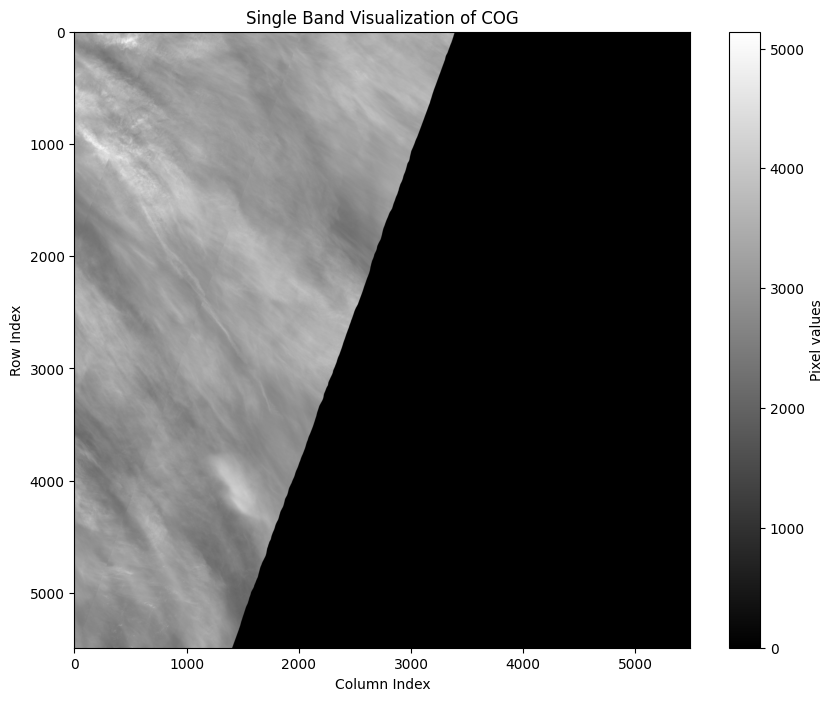

In [24]:
plot_RGB_cog(rgb)
plot_band_cog(B8A_cog) - NIR
plot_band_cog(B12_cog) - SWIR